# Football Shot Quality Prediction with Defensive Context

## Problem

Two shots taken from the same position can have very different scoring
probabilities. Defenders, goalkeeper positioning, body part, and pressure
can change the difficulty of the opportunity.

We predict whether a non-penalty shot becomes a goal.

The predicted probability is our expected-goals estimate, or xG.
An xG of 0.20 means an estimated 20% scoring probability.

## Main question

Does defensive positioning improve prediction beyond shot location and
basic shot characteristics?

## Models

1. Logistic regression using distance and angle.
2. CatBoost using location and basic shot characteristics.
3. CatBoost adding defensive context.
4. The defensive-context model with probability calibration.

Comparing models 2 and 3 isolates the additional predictive value of the
defensive features.

## Data and scope

Source: StatsBomb Open Data.
Competitions: Women's World Cups in 2019 and 2023.

We use the shot freeze frames inside event data. These record visible
player positions at the time of the shot.

This is retrospective shot-quality analysis, not match-result prediction
or a live tracking system.

Source repository: https://github.com/statsbomb/open-data
Review its attribution and usage requirements before publishing.

In [3]:
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm.auto import tqdm
from catboost import CatBoostClassifier, Pool
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    log_loss, brier_score_loss, roc_auc_score,
    average_precision_score, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve

SEED = 42
BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
CACHE = Path("data/statsbomb")
CACHE.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## 1. Download and cache the event data

The first run downloads match event files and can take several minutes.
Later runs reuse the local cache.

Download failures raise an error rather than silently dropping matches.
Only four downloads run simultaneously.

The model uses shot outcomes as labels. StatsBomb's own xG estimates,
shot end locations, and other post-shot information are excluded from inputs.

In [4]:
def get_json(relative_path):
    destination = CACHE / relative_path

    if destination.exists():
        return json.loads(destination.read_text(encoding="utf-8"))

    retry = Retry(
        total=4, backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504]
    )

    with requests.Session() as session:
        session.mount("https://", HTTPAdapter(max_retries=retry))
        response = session.get(
            f"{BASE_URL}/{relative_path}", timeout=(15, 90)
        )
        response.raise_for_status()
        payload = response.json()

    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(json.dumps(payload), encoding="utf-8")
    return payload


match_rows = []
for season_id, year in [(30, 2019), (107, 2023)]:
    season_matches = get_json(f"matches/72/{season_id}.json")
    for match in season_matches:
        match_rows.append({
            "match_id": match["match_id"],
            "year": year,
            "match_date": match["match_date"],
            "home": match["home_team"]["home_team_name"],
            "away": match["away_team"]["away_team_name"]
        })

matches = pd.DataFrame(match_rows).drop_duplicates("match_id")
display(matches.groupby("year").size().rename("matches").to_frame())

,matches
year,
2019,52
2023,64


In [5]:
def load_match_shots(match_id):
    events = get_json(f"events/{match_id}.json")
    return [
        dict(event, match_id=match_id)
        for event in events
        if event.get("type", {}).get("name") == "Shot"
    ]


match_ids = matches["match_id"].tolist()

with ThreadPoolExecutor(max_workers=4) as executor:
    shot_lists = list(tqdm(
        executor.map(load_match_shots, match_ids),
        total=len(match_ids),
        desc="Loading matches"
    ))

raw_shots = [shot for match_shots in shot_lists for shot in match_shots]

print("Matches loaded:", len(match_ids))
print("Raw shot events:", len(raw_shots))
print("Example shot fields:", sorted(raw_shots[0]["shot"].keys()))

Loading matches:   0%|          | 0/116 [00:00<?, ?it/s]

Matches loaded: 116
Raw shot events: 2992
Example shot fields: ['body_part', 'end_location', 'freeze_frame', 'key_pass_id', 'outcome', 'statsbomb_xg', 'technique', 'type']


## 2. Engineer shot geometry and defensive context

StatsBomb uses a 120 × 80 coordinate system. For shot events, the attacking
goal is represented at x = 120, with posts at y = 36 and y = 44.

Distances below use these coordinate units, not metres.

We calculate:

- Distance to the centre of goal.
- Angle subtended by the two goalposts.
- Distance to the nearest visible outfield opponent.
- Visible outfield opponents inside the triangle from shooter to goalposts.
- Goalkeeper distance from the shooter and position relative to goal.

The shooting triangle is an approximate obstruction measure. It does not
represent a defender's body size, movement, or actual ability to block.

An absent goalkeeper or defender is treated as unknown, not infinitely far
away. Even a nonempty freeze frame can omit off-camera players.

In [6]:
GOAL = np.array([120.0, 40.0])
POST_A = np.array([120.0, 36.0])
POST_B = np.array([120.0, 44.0])


def cross2(a, b):
    return a[0] * b[1] - a[1] * b[0]


def inside_shooting_triangle(point, shooter):
    a = POST_A - shooter
    b = POST_B - shooter
    q = point - shooter
    denominator = cross2(a, b)

    if abs(denominator) < 1e-9:
        return False

    u = cross2(q, b) / denominator
    v = cross2(a, q) / denominator
    return u >= 0 and v >= 0 and u + v <= 1


def extract_shot(event):
    shot = event["shot"]
    location = event.get("location")

    # Remove penalties and penalty-shootout events.
    if shot.get("type", {}).get("name") == "Penalty":
        return None
    if event.get("period", 0) == 5:
        return None
    if not location or len(location) < 2:
        return None

    shooter = np.array(location[:2], dtype=float)
    post_a = POST_A - shooter
    post_b = POST_B - shooter

    angle = np.arctan2(
        abs(cross2(post_a, post_b)),
        np.dot(post_a, post_b)
    )

    frame = shot.get("freeze_frame") or []
    opponents = [
        p for p in frame
        if p.get("teammate") is False and len(p.get("location", [])) >= 2
    ]

    defenders = [
        np.array(p["location"][:2], dtype=float)
        for p in opponents
        if p.get("position", {}).get("name") != "Goalkeeper"
    ]

    keepers = [
        np.array(p["location"][:2], dtype=float)
        for p in opponents
        if p.get("position", {}).get("name") == "Goalkeeper"
    ]

    keeper = min(
        keepers, key=lambda p: np.linalg.norm(p - GOAL)
    ) if keepers else None

    return {
        "shot_id": event["id"],
        "match_id": event["match_id"],
        "player": event.get("player", {}).get("name", "Unknown"),
        "team": event.get("team", {}).get("name", "Unknown"),
        "x": shooter[0],
        "y": shooter[1],
        "distance": np.linalg.norm(shooter - GOAL),
        "angle": angle,
        "body_part": shot.get("body_part", {}).get("name", "Unknown"),
        "shot_type": shot.get("type", {}).get("name", "Unknown"),
        "first_time": int(shot.get("first_time", False)),
        "under_pressure": int(event.get("under_pressure", False)),
        "frame_available": int(bool(frame)),
        "visible_defenders": len(defenders) if frame else np.nan,
        "nearest_defender": min(
            (np.linalg.norm(p - shooter) for p in defenders),
            default=np.nan
        ),
        "defenders_in_triangle": sum(
            inside_shooting_triangle(p, shooter) for p in defenders
        ) if frame else np.nan,
        "keeper_visible": int(keeper is not None),
        "keeper_distance": (
            np.linalg.norm(keeper - shooter) if keeper is not None else np.nan
        ),
        "keeper_depth": 120 - keeper[0] if keeper is not None else np.nan,
        "keeper_lateral": abs(keeper[1] - 40) if keeper is not None else np.nan,
        "goal": int(shot.get("outcome", {}).get("name") == "Goal")
    }

In [7]:
rows = [extract_shot(event) for event in raw_shots]
shots = pd.DataFrame([row for row in rows if row is not None])

shots = shots.drop_duplicates("shot_id").merge(
    matches[["match_id", "year", "match_date"]],
    on="match_id", how="left", validate="many_to_one"
)

assert np.isfinite(shots[["x", "y", "distance", "angle"]]).all().all()

display(shots.groupby("year").agg(
    shots=("goal", "size"),
    goals=("goal", "sum"),
    scoring_rate=("goal", "mean"),
    freeze_frame_coverage=("frame_available", "mean"),
    goalkeeper_coverage=("keeper_visible", "mean")
).round(3))

display(shots.isna().sum().rename("missing_values").to_frame())

,shots,goals,scoring_rate,freeze_frame_coverage,goalkeeper_coverage
year,,,,,
2019,1281,120,0.094,1.0,0.999
2023,1608,136,0.085,1.0,1.000


,missing_values
shot_id,0
match_id,0
player,0
team,0
x,0
y,0
distance,0
angle,0
body_part,0
shot_type,0


## 3. Separate matches into four partitions

We reserve separate matches for:

- Training: fit model parameters.
- Validation: select the number of boosting iterations.
- Calibration: fit a probability adjustment.
- Testing: evaluate the finished models.

No match appears in more than one partition.

This evaluates unseen matches from the same pooled tournaments. It does not
test forecasting a future tournament or generalization to men's football.

In [8]:
def split_matches(frame, test_size, seed):
    splitter = GroupShuffleSplit(
        n_splits=1, test_size=test_size, random_state=seed
    )
    left, right = next(splitter.split(frame, groups=frame["match_id"]))
    return frame.iloc[left].copy(), frame.iloc[right].copy()


development, test = split_matches(shots, 0.15, SEED)
development, calibration = split_matches(
    development, 0.15 / 0.85, SEED + 1
)
train, validation = split_matches(
    development, 0.15 / 0.70, SEED + 2
)

partitions = {
    "train": train, "validation": validation,
    "calibration": calibration, "test": test
}

summary = []
seen_matches = set()

for name, frame in partitions.items():
    ids = set(frame["match_id"])
    assert not seen_matches.intersection(ids)
    seen_matches.update(ids)
    assert frame["goal"].nunique() == 2, f"{name} needs both outcomes"

    summary.append({
        "partition": name,
        "matches": len(ids),
        "shots": len(frame),
        "goals": frame["goal"].sum(),
        "scoring_rate": frame["goal"].mean()
    })

display(pd.DataFrame(summary).round(3))

,partition,matches,shots,goals,scoring_rate
0,train,62,1543,123,0.080
1,validation,18,457,43,0.094
2,calibration,18,414,37,0.089
3,test,18,475,53,0.112


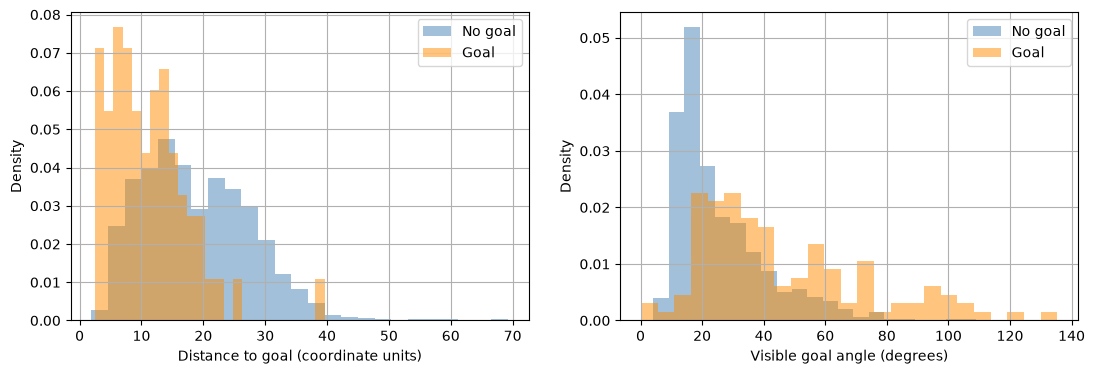

,shots,scoring_rate
body_part,,
Right Foot,843,0.057
Left Foot,390,0.100
Head,298,0.104
Other,12,0.417


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in [(0, "steelblue"), (1, "darkorange")]:
    subset = train.loc[train["goal"] == label]
    axes[0].hist(
        subset["distance"], bins=25, density=True,
        alpha=0.5, label="Goal" if label else "No goal", color=color
    )
    axes[1].hist(
        np.degrees(subset["angle"]), bins=25, density=True,
        alpha=0.5, label="Goal" if label else "No goal", color=color
    )

axes[0].set(xlabel="Distance to goal (coordinate units)", ylabel="Density")
axes[1].set(xlabel="Visible goal angle (degrees)", ylabel="Density")
axes[0].legend()
axes[1].legend()
plt.show()

display(train.groupby("body_part").agg(
    shots=("goal", "size"),
    scoring_rate=("goal", "mean")
).sort_values("shots", ascending=False).round(3))

## Data and features

The final dataset contains 2,889 non-penalty shots and 256 goals from 116 matches across the 2019 and 2023 Women's World Cups. The overall scoring rate is approximately 8.9%, making goals the minority outcome.

The training plots show that goals tend to come from shorter distances and wider visible goal angles. However, the distributions overlap: location helps estimate scoring probability but cannot fully distinguish goals from unsuccessful shots. Distances are measured in StatsBomb coordinate units, not metres.

Defensive features describe the situation around the shooter: goalkeeper position, nearest visible defender, and visible opponents inside the shooting triangle. These provide information that shot location alone misses. The triangle is an approximate shooting corridor, and freeze frames describe recorded players rather than guaranteed complete defensive coverage.

Every retained shot has a freeze frame, so `frame_available` is constant and cannot help distinguish outcomes in this dataset. Only one shot lacks goalkeeper geometry. This means the experiment provides little evidence about performance when freeze-frame information is unavailable.

Matches are separated into training, validation, calibration, and test sets, containing 62, 18, 18, and 18 matches respectively. Keeping entire matches together prevents shots from the same match appearing in multiple partitions. However, the split pools both tournaments, so it evaluates unseen matches rather than prediction on a future tournament.

The target and post-shot information are excluded from the predictors. The model therefore estimates scoring probability from the recorded shooting situation rather than information about how the shot ended.

## 4. Fit the location baseline and the two CatBoost models

The logistic baseline uses distance and angle.

Both CatBoost models use the same training procedure. The full model adds
defensive context to the basic model, making their comparison meaningful.

We retain natural goal prevalence. Class weighting or oversampling could
distort the probabilities that we want to interpret as xG.

Model settings are fixed beforehand. Validation selects stopping iterations;
the test set is not used for training, early stopping, or calibration.

In [10]:
LOCATION = ["distance", "angle"]
CATEGORICAL = ["body_part", "shot_type"]

BASIC = LOCATION + CATEGORICAL + ["first_time", "under_pressure"]

DEFENSIVE = [
    "frame_available", "visible_defenders", "nearest_defender",
    "defenders_in_triangle", "keeper_visible", "keeper_distance",
    "keeper_depth", "keeper_lateral"
]

FULL = BASIC + DEFENSIVE

baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
)
baseline.fit(train[LOCATION], train["goal"])


def fit_catboost(features):
    model = CatBoostClassifier(
        iterations=1500,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=5,
        loss_function="Logloss",
        eval_metric="Logloss",
        random_seed=SEED,
        thread_count=4,
        allow_writing_files=False,
        verbose=False
    )

    model.fit(
        train[features], train["goal"],
        cat_features=CATEGORICAL,
        eval_set=(validation[features], validation["goal"]),
        early_stopping_rounds=100,
        verbose=False
    )
    return model


basic_model = fit_catboost(BASIC)
full_model = fit_catboost(FULL)

print("Basic model trees:", basic_model.tree_count_)
print("Defensive model trees:", full_model.tree_count_)

Basic model trees: 73
Defensive model trees: 84


## 5. Calibrate the defensive model

A model can rank opportunities well while systematically overstating or
understating scoring probabilities.

We fit a logistic calibration function to the full model's raw scores using
only the calibration matches. The full model remains fixed.

Calibration is not guaranteed to improve the final test results. We evaluate
both the raw and calibrated predictions.

In [11]:
calibration_scores = full_model.predict(
    calibration[FULL], prediction_type="RawFormulaVal"
).reshape(-1, 1)

calibrator = LogisticRegression(C=1.0, max_iter=2000)
calibrator.fit(calibration_scores, calibration["goal"])

test_raw_scores = full_model.predict(
    test[FULL], prediction_type="RawFormulaVal"
).reshape(-1, 1)

probabilities = {
    "Constant prevalence": np.full(len(test), train["goal"].mean()),
    "Location logistic": baseline.predict_proba(test[LOCATION])[:, 1],
    "Basic CatBoost": basic_model.predict_proba(test[BASIC])[:, 1],
    "Defensive CatBoost": full_model.predict_proba(test[FULL])[:, 1],
    "Calibrated defensive": calibrator.predict_proba(test_raw_scores)[:, 1]
}

evaluation = []
for name, probability in probabilities.items():
    evaluation.append({
        "model": name,
        "log_loss": log_loss(test["goal"], probability, labels=[0, 1]),
        "Brier": brier_score_loss(test["goal"], probability),
        "ROC_AUC": roc_auc_score(test["goal"], probability),
        "average_precision": average_precision_score(test["goal"], probability),
        "predicted_goals": probability.sum(),
        "actual_goals": int(test["goal"].sum())
    })

results = pd.DataFrame(evaluation).sort_values("log_loss")
display(results.round(4))

,model,log_loss,Brier,ROC_AUC,average_precision,predicted_goals,actual_goals
4,Calibrated defensive,0.3051,0.0862,0.7514,0.3713,42.2635,53
3,Defensive CatBoost,0.3086,0.0888,0.7514,0.3713,39.6975,53
2,Basic CatBoost,0.3208,0.0912,0.7035,0.3111,45.4101,53
1,Location logistic,0.3305,0.0929,0.7005,0.2813,37.5721,53
0,Constant prevalence,0.3560,0.1001,0.5000,0.1116,37.8645,53


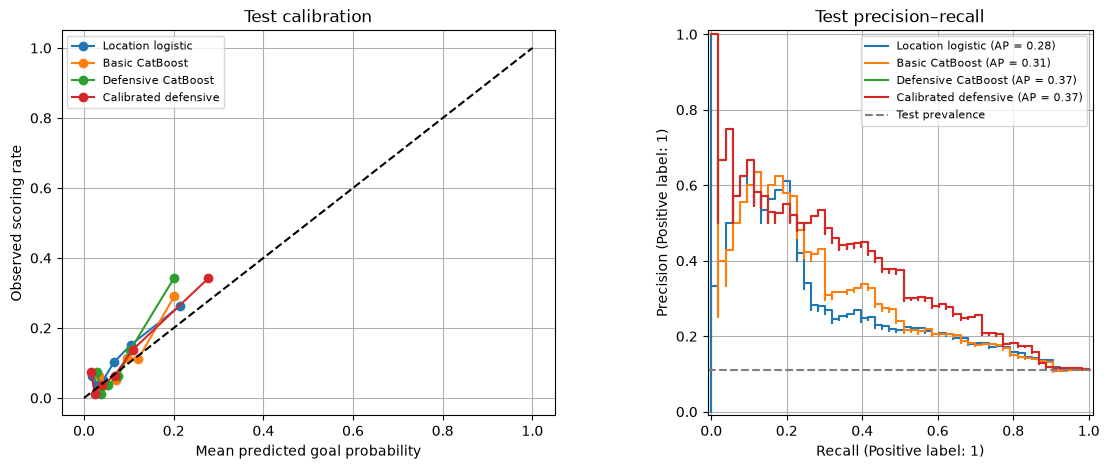

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probability in probabilities.items():
    if name == "Constant prevalence":
        continue

    observed, predicted = calibration_curve(
        test["goal"], probability, n_bins=6, strategy="quantile"
    )
    axes[0].plot(predicted, observed, marker="o", label=name)

    PrecisionRecallDisplay.from_predictions(
        test["goal"], probability, name=name, ax=axes[1]
    )

axes[0].plot([0, 1], [0, 1], "--", color="black")
axes[0].set(
    xlabel="Mean predicted goal probability",
    ylabel="Observed scoring rate",
    title="Test calibration"
)
axes[0].legend(fontsize=8)

axes[1].axhline(
    test["goal"].mean(), linestyle="--",
    color="grey", label="Test prevalence"
)
axes[1].set_title("Test precision–recall")
axes[1].legend(fontsize=8)
plt.show()

## 6. Quantify uncertainty in the defensive-context improvement

A small difference on one split may be noise.

We bootstrap entire test matches, preserving dependence among shots within a
match. The statistic is:

basic-model log loss − defensive-model log loss

A positive value favours defensive context.

This interval measures uncertainty across the held-out matches conditional
on the fitted models. It does not include training or split uncertainty.

In [13]:
test_analysis = test.copy()
test_analysis["basic_xg"] = probabilities["Basic CatBoost"]
test_analysis["defensive_xg"] = probabilities["Defensive CatBoost"]
test_analysis["calibrated_xg"] = probabilities["Calibrated defensive"]

def binary_losses(target, probability):
    p = np.clip(np.asarray(probability), 1e-8, 1 - 1e-8)
    y = np.asarray(target)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


test_analysis["loss_improvement"] = (
    binary_losses(test["goal"], probabilities["Basic CatBoost"])
    - binary_losses(test["goal"], probabilities["Defensive CatBoost"])
)

group_losses = test_analysis.groupby("match_id").agg(
    total_improvement=("loss_improvement", "sum"),
    shots=("goal", "size")
)

rng = np.random.default_rng(SEED)
totals = group_losses["total_improvement"].to_numpy()
counts = group_losses["shots"].to_numpy()

draws = rng.integers(
    0, len(group_losses), size=(2000, len(group_losses))
)
bootstrap_gains = totals[draws].sum(axis=1) / counts[draws].sum(axis=1)

point_gain = totals.sum() / counts.sum()
low, high = np.quantile(bootstrap_gains, [0.025, 0.975])

print(f"Log-loss improvement from defensive features: {point_gain:.4f}")
print(f"95% match-bootstrap interval: [{low:.4f}, {high:.4f}]")
print("Positive values favour defensive context.")

Log-loss improvement from defensive features: 0.0122
95% match-bootstrap interval: [0.0033, 0.0213]
Positive values favour defensive context.


## Predictive performance and calibration

The test set contains 475 shots and 53 goals, a scoring rate of 11.2%.

| Model | Log loss ↓ | Brier score ↓ | ROC AUC ↑ | Average precision ↑ |
|---|---:|---:|---:|---:|
| Constant prevalence | 0.3560 | 0.1001 | 0.5000 | 0.1116 |
| Location logistic | 0.3305 | 0.0929 | 0.7005 | 0.2813 |
| Basic CatBoost | 0.3208 | 0.0912 | 0.7035 | 0.3111 |
| Defensive CatBoost | 0.3086 | 0.0888 | 0.7514 | 0.3713 |
| Calibrated defensive | 0.3051 | 0.0862 | 0.7514 | 0.3713 |

Adding defensive features improves all four metrics relative to basic CatBoost. Log loss decreases by 0.0122, approximately 3.8%, while ROC AUC increases from 0.7035 to 0.7514. Average precision rises from 0.3111 to 0.3713, indicating better ranking of goals among the higher-scored shots. Average precision summarizes the precision–recall curve; it is not precision at one decision threshold.

The 95% match-bootstrap interval for the log-loss improvement is [0.0033, 0.0213]. Because the interval remains above zero, the held-out results support a benefit from defensive context. This uncertainty estimate preserves within-match dependence, but it is conditional on the fitted models and only 18 test matches. It does not capture uncertainty from retraining or choosing another split.

Calibration further improves log loss from 0.3086 to 0.3051 and Brier score from 0.0888 to 0.0862. ROC AUC and average precision remain unchanged because the fitted calibration transformation preserves the ordering of shots: it adjusts probability estimates rather than ranking.

Calibration does not eliminate underprediction. The calibrated model assigns 42.26 expected goals to shots that produced 53 goals, compared with 39.70 expected goals before calibration. Its average predicted probability is about 8.9%, below the observed test scoring rate of 11.2%.

The reliability plot also shows remaining departures from the diagonal, including underprediction in the highest-probability bin. With only 53 test goals and 37 calibration goals, the curve should not be treated as a precise assessment of every probability range.

Basic CatBoost produces a total closer to 53 goals, but its shot-level probability scores are worse. Matching the aggregate goal count alone is therefore insufficient for judging an expected-goals model.

## 7. Explain individual predictions with SHAP

CatBoost's SHAP contributions sum with a base value to reconstruct the raw
model score, expressed in log-odds.

Positive contributions raise the raw predicted scoring chance; negative
contributions lower it.

These explain the uncalibrated CatBoost model. The separate calibration
function changes its final probabilities.

We inspect both a high-probability miss and a low-probability goal. These are
deliberately selected surprising outcomes, not representative observations.

,feature,mean_absolute_SHAP
11,keeper_distance,0.2151
1,angle,0.2029
0,distance,0.1584
7,visible_defenders,0.0855
8,nearest_defender,0.0678
12,keeper_depth,0.0584
9,defenders_in_triangle,0.0531
4,first_time,0.0444
2,body_part,0.0363
13,keeper_lateral,0.0299


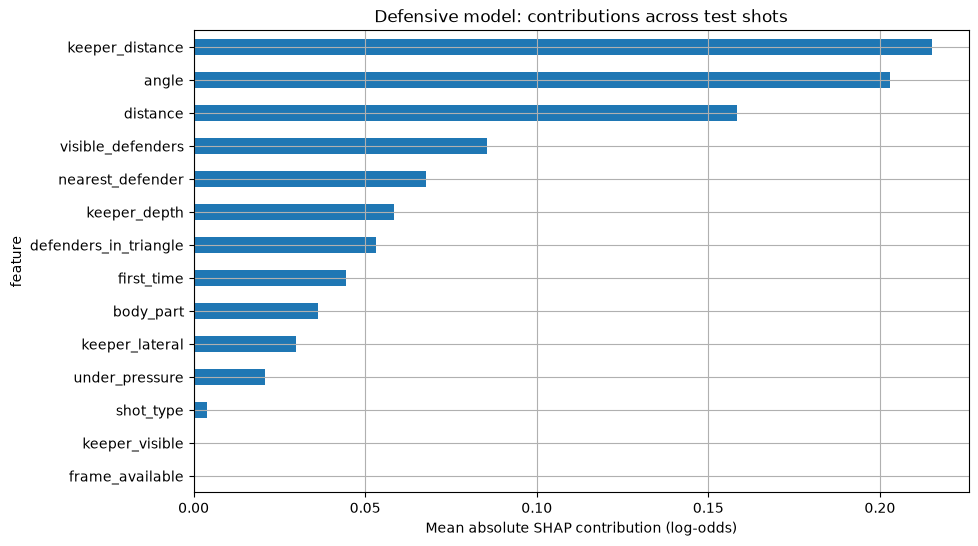

In [14]:
test_pool = Pool(test[FULL], cat_features=CATEGORICAL)
shap_values = full_model.get_feature_importance(
    test_pool, type="ShapValues"
)

importance = pd.DataFrame({
    "feature": FULL,
    "mean_absolute_SHAP": np.abs(shap_values[:, :-1]).mean(axis=0)
}).sort_values("mean_absolute_SHAP", ascending=False)

display(importance.round(4))

importance.sort_values("mean_absolute_SHAP").plot.barh(
    x="feature", y="mean_absolute_SHAP", legend=False, figsize=(10, 6)
)
plt.xlabel("Mean absolute SHAP contribution (log-odds)")
plt.title("Defensive model: contributions across test shots")
plt.show()

High-probability miss
Reconstructed raw xG: 0.4811


,player,team,goal,distance,body_part,defensive_xg,calibrated_xg
336,Marina Hegering,Germany Women's,0,3.744,Head,0.481,0.738


Low-probability goal
Reconstructed raw xG: 0.0259


,player,team,goal,distance,body_part,defensive_xg,calibrated_xg
1423,Marta Alexandra Cox Villarreal,Panama Women's,1,34.051,Right Foot,0.026,0.013


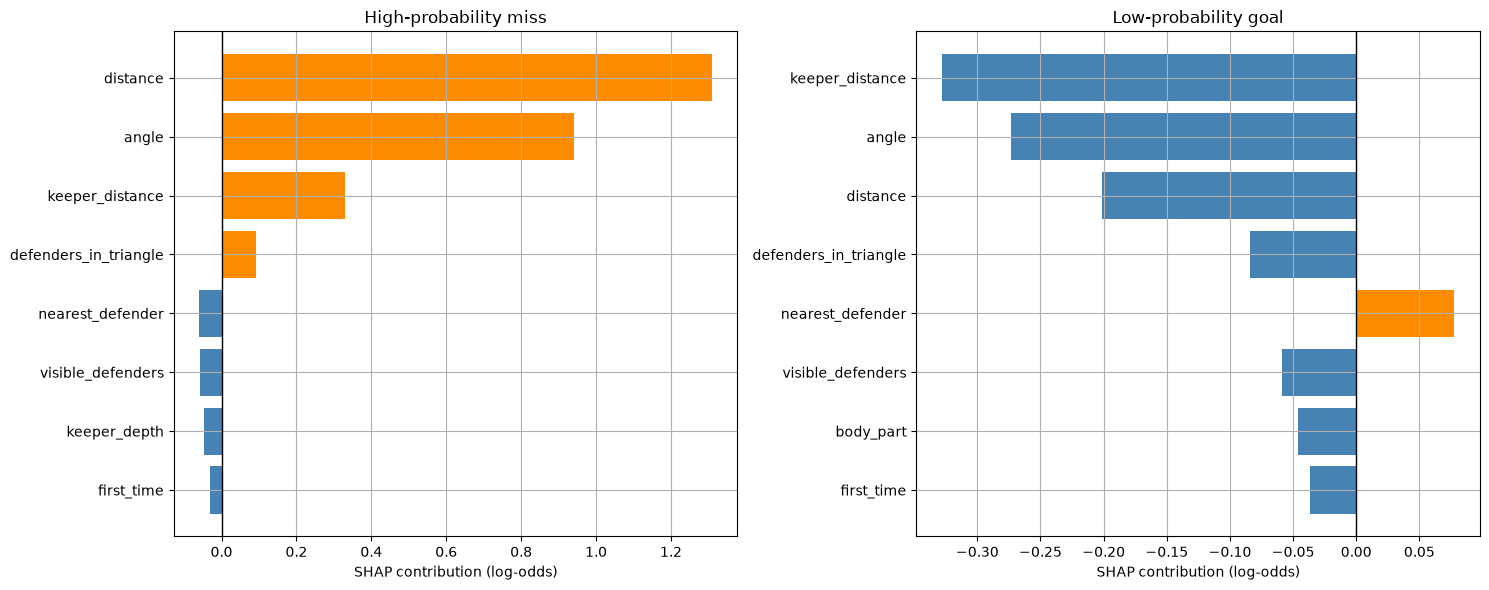

In [15]:
examples = {
    "High-probability miss": test_analysis.loc[
        test_analysis["goal"] == 0, "defensive_xg"
    ].idxmax(),
    "Low-probability goal": test_analysis.loc[
        test_analysis["goal"] == 1, "defensive_xg"
    ].idxmin()
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (title, index) in zip(axes, examples.items()):
    position = test.index.get_loc(index)
    values = shap_values[position, :-1]
    base_value = shap_values[position, -1]

    top = np.argsort(np.abs(values))[-8:]
    colors = np.where(values[top] >= 0, "darkorange", "steelblue")

    ax.barh(np.array(FULL)[top], values[top], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set(title=title, xlabel="SHAP contribution (log-odds)")

    raw_score = base_value + values.sum()
    reconstructed = 1 / (1 + np.exp(-raw_score))

    print(title)
    print(f"Reconstructed raw xG: {reconstructed:.4f}")
    display(test_analysis.loc[[index], [
        "player", "team", "goal", "distance", "body_part",
        "defensive_xg", "calibrated_xg"
    ]].round(3))

plt.tight_layout()
plt.show()

## 8. Visualize the actual shooting situations

The pitch diagrams show the recorded freeze frame for each selected example.

They help explain the geometric features, but missing players remain unknown.
A visual explanation should not imply that every player was captured.

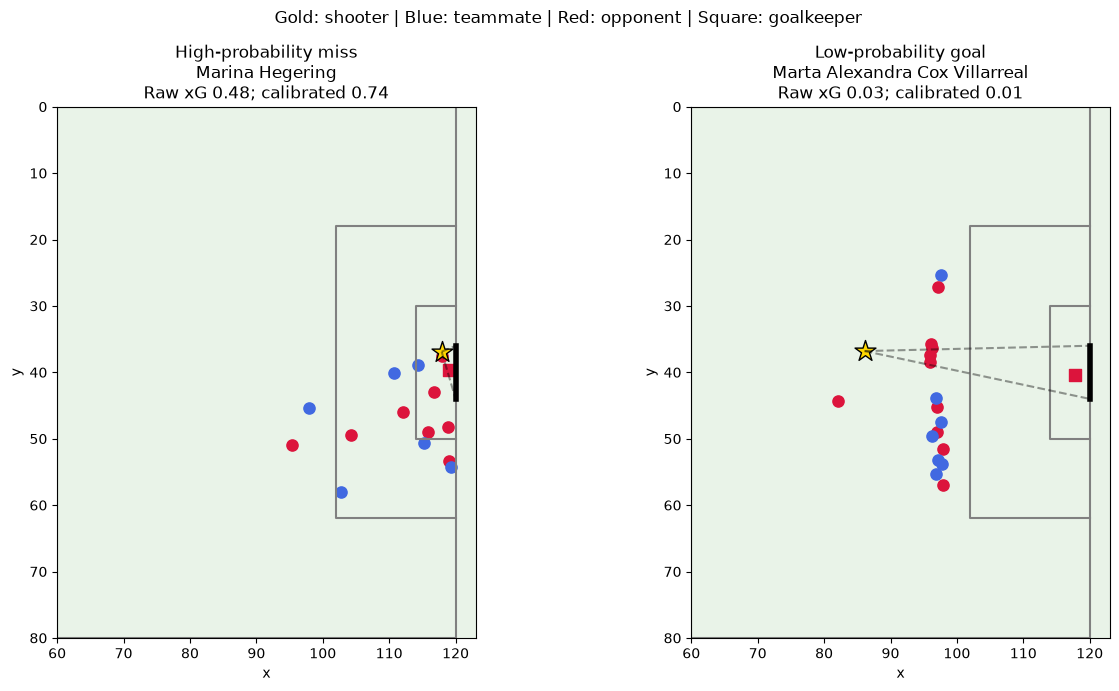

In [16]:
events_by_id = {event["id"]: event for event in raw_shots}


def draw_half_pitch(ax):
    ax.set_facecolor("#e9f3e8")
    ax.plot([60, 120, 120, 60, 60], [0, 0, 80, 80, 0], color="grey")
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color="grey")
    ax.plot([120, 114, 114, 120], [30, 30, 50, 50], color="grey")
    ax.plot([120, 120], [36, 44], color="black", linewidth=4)
    ax.set(xlim=(60, 123), ylim=(80, 0), xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, (title, index) in zip(axes, examples.items()):
    row = test_analysis.loc[index]
    event = events_by_id[row["shot_id"]]
    draw_half_pitch(ax)

    for player in event["shot"].get("freeze_frame", []):
        location = player.get("location")
        if not location:
            continue

        teammate = player.get("teammate", False)
        keeper = player.get("position", {}).get("name") == "Goalkeeper"
        color = "royalblue" if teammate else "crimson"
        ax.scatter(
            *location[:2], c=color,
            marker="s" if keeper else "o", s=65
        )

    ax.scatter(row["x"], row["y"], marker="*", s=250, c="gold", edgecolor="black")
    for post_y in [36, 44]:
        ax.plot(
            [row["x"], 120], [row["y"], post_y],
            "--", color="black", alpha=0.4
        )

    ax.set_title(
        f"{title}\n{row['player']}\n"
        f"Raw xG {row['defensive_xg']:.2f}; "
        f"calibrated {row['calibrated_xg']:.2f}"
    )

fig.suptitle("Gold: shooter | Blue: teammate | Red: opponent | Square: goalkeeper")
plt.tight_layout()
plt.show()

In [17]:
test_analysis["context_change"] = (
    test_analysis["defensive_xg"] - test_analysis["basic_xg"]
)

largest_changes = test_analysis.loc[
    test_analysis["context_change"].abs().nlargest(10).index,
    [
        "player", "team", "goal", "distance", "body_part",
        "nearest_defender", "defenders_in_triangle",
        "keeper_visible", "basic_xg", "defensive_xg", "context_change"
    ]
]

display(largest_changes.round(3))

,player,team,goal,distance,body_part,nearest_defender,defenders_in_triangle,keeper_visible,basic_xg,defensive_xg,context_change
424,Mallory Diane Swanson,United States Women's,1,4.789,Left Foot,4.851,0,1,0.301,0.481,0.180
838,Eva Sofia Jakobsson,Sweden Women's,0,13.147,Right Foot,3.962,0,1,0.137,0.262,0.126
855,Barbara Bonansea,Italy Women's,1,12.523,Right Foot,5.235,0,1,0.109,0.213,0.105
1272,Megan Anna Rapinoe,United States Women's,0,5.701,Right Foot,1.315,1,1,0.296,0.194,-0.102
318,Lina Magull,Germany Women's,1,13.462,Right Foot,2.040,0,1,0.098,0.194,0.096
328,Emma Stina Blackstenius,Sweden Women's,0,14.356,Right Foot,3.162,1,1,0.092,0.184,0.093
420,Megan Anna Rapinoe,United States Women's,1,11.772,Right Foot,1.800,0,1,0.145,0.235,0.090
736,Jill Scott,England Women's,0,7.234,Right Foot,0.500,2,1,0.207,0.119,-0.089
819,Emma Stina Blackstenius,Sweden Women's,0,10.728,Right Foot,1.640,0,1,0.150,0.236,0.086
1078,Min-A Lee,Korea Republic Women's,0,18.804,Right Foot,2.319,0,1,0.071,0.153,0.082


## Model explanations and shot examples

Goalkeeper distance has the largest mean absolute SHAP contribution (0.2151), followed by visible goal angle (0.2029) and shot distance (0.1584). Visible defender count, nearest-defender distance, and goalkeeper depth also contribute to predictions.

These values measure the magnitude of contributions to the uncalibrated model's log-odds. They are not percentage-point changes in scoring probability and do not establish causal effects. Goalkeeper distance and shot distance also share geometric information, so their importance should not be interpreted as independent contributions.

`frame_available` has zero importance because it is constant. The near-zero contribution of `keeper_visible` reflects its almost complete lack of variation here, rather than evidence that goalkeeper visibility never matters.

For Marina Hegering's selected missed header, the raw model probability is 48.1%, increasing to 73.8% after calibration. Short shot distance and a wide goal angle provide the largest positive SHAP contributions, with goalkeeper distance also increasing the raw score. This is the highest-probability miss selected by the notebook, not a certain goal: even a calibrated probability of 73.8% leaves a 26.2% chance of no goal.

For Marta Alexandra Cox Villarreal's selected goal, the raw probability is 2.59%, decreasing to approximately 1.3% after calibration. Goalkeeper distance, goal angle, and shot distance lower the raw score, while nearest-defender distance partly offsets those contributions. A low-probability goal is possible and does not, by itself, invalidate a probability model.

The SHAP plots explain the raw CatBoost predictions, not the final calibrated probabilities. They display only the eight largest contributions for each example; reconstructing the prediction requires all feature contributions and the base value.

Comparing the two CatBoost models illustrates how context can change shot evaluation. Mallory Swanson's shot increases from 0.301 to 0.481, whereas Jill Scott's decreases from 0.207 to 0.119. Scott's recorded situation includes a defender only 0.5 coordinate units away and two defenders inside the shooting triangle, consistent with a more obstructed opportunity.

These differences compare separately fitted models. They do not isolate the causal effect of moving one defender, and the actual outcome of a single shot cannot establish which probability was better.

In [18]:
team_summary = test_analysis.groupby("team").agg(
    matches=("match_id", "nunique"),
    shots=("goal", "size"),
    goals=("goal", "sum"),
    total_xg=("calibrated_xg", "sum"),
    xg_per_shot=("calibrated_xg", "mean")
)

team_summary["goals_minus_xg"] = (
    team_summary["goals"] - team_summary["total_xg"]
)
team_summary["xg_per_match"] = (
    team_summary["total_xg"] / team_summary["matches"]
)

display(team_summary.sort_values("total_xg", ascending=False).round(3))

,matches,shots,goals,total_xg,xg_per_shot,goals_minus_xg,xg_per_match
team,,,,,,,
United States Women's,3,58,15,6.980,0.120,8.020,2.327
Spain Women's,3,74,3,6.284,0.085,-3.284,2.095
Sweden Women's,2,36,4,4.813,0.134,-0.813,2.406
France Women's,3,65,9,4.259,0.066,4.741,1.420
England Women's,2,26,3,3.557,0.137,-0.557,1.779
Germany Women's,3,37,3,3.268,0.088,-0.268,1.089
Japan Women's,2,35,3,3.058,0.087,-0.058,1.529
Norway Women's,1,30,4,3.017,0.101,0.983,3.017
Australia Women's,2,27,1,2.246,0.083,-1.246,1.123


## Final conclusions

The experiment supports the practical value of defensive context for expected-goals modelling. Adding goalkeeper and defender geometry improves both probability scores and ranking relative to the basic shot-feature model. The calibrated defensive model achieves the lowest test log loss (0.3051) and Brier score (0.0862), although aggregate scoring remains underestimated.

The team summary demonstrates how expected goals can separate shot volume, estimated chance quality, and observed scoring. In the held-out sample, the United States produces 6.98 expected goals from 58 shots and scores 15 goals. Spain produces 6.28 expected goals from 74 shots and scores three. The United States has higher estimated average shot quality (0.120 versus 0.085), despite taking fewer shots.

These differences describe the retained non-penalty shots in the test sample, not complete tournament performances or necessarily full match scorelines. Each team contributes only one to three matches. Goals above or below expected goals can reflect finishing, goalkeeper performance, randomness, and model error; these results cannot establish persistent finishing skill.

The model is useful for reviewing shooting opportunities and identifying situations that location-only analysis misses. Its limitations include the small evaluation sample, incomplete spatial context, correlated geometric features, and remaining calibration error.

A useful next validation would train on 2019 and evaluate on 2023, with model selection and calibration restricted to the earlier data. This would test transfer to a later tournament, which the current pooled match split does not measure.